# 📊 Topic 1: Measures of Central Tendency — Finding the Typical Value
**Course**: CMPS 360 / Data Analytics  
**Context**: Qatar Real-World Applications (Trainee Performance, Residential Rental Market, Retail Payments)  
**Lecture Reference**: Chapter 3: Statistics for Data Insights (Slides 18–24)

---

## 🎯 Learning Objectives
By the end of this demo, you will be able to:
1. Explain what **"typical"** means using the three primary centres: **Mean ($\bar{x}$)**, **Median ($M$)**, and **Mode ($Mo$)**.
2. Verify calculations by hand on small datasets and compute them using `pandas`.
3. Understand why the **Median is robust to outliers** while the **Mean is sensitive to extremes**.
4. Apply the **Center Gap Test** ($|\bar{x} - M| / M$) to decide which center to report.
5. Work with categorical data using **frequency counts**, **proportions**, and the **Mode**.
6. Follow the golden rule: *"Always split before you summarize"* using `groupby()` in pandas.

---

## 🇶🇦 Qatar Real-World Scenarios
In this notebook, we examine three realistic datasets:
* **Qatar Trainee Exam Scores** (`data/trainee_scores.csv`): A small 10-student cohort to verify statistics by hand.
* **Doha & Lusail Residential Rents** (`data/qatar_rents.csv`): Real estate listings demonstrating why the Median is the standard metric for housing costs when luxury penthouses are present.
* **Qatar Retail Payment Methods** (`data/payment_methods.csv`): 200 consumer transactions illustrating how the Mode guides payment terminal capacity.


In [1]:
# Step 0: Import required analytical and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style for undergraduate demos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. What "Typical" Means: The Three Centres

A measure of central tendency provides a single summary number that represents the center or typical value of a dataset.

| Measure | Mathematical Symbol | Definition | Best Used For |
| :--- | :---: | :--- | :--- |
| **Arithmetic Mean** | $\bar{x} = \frac{\sum x_i}{n}$ | The arithmetic balance point. Sum of all values divided by count $n$. Uses the magnitude of every value. | Symmetric data, and any quantity that must multiply up to a total (e.g., total budget). |
| **Median** | $M$ | The middle value once data is sorted in order. Uses position (rank) only, not magnitude. | Skewed data, or datasets with extreme outliers (e.g., incomes, house prices). |
| **Mode** | $Mo$ | The most frequently occurring value in the dataset. | Categorical data, survey levels, or repeated discrete values. |

> **Key Rule from Lecture (Slide 19):**  
> In a perfectly symmetric distribution, $\bar{x} = M = Mo$. The size of the gap between the mean and median is itself a direct measurement of asymmetry!


## 2. Worked Example: Qatar Trainee Exam Scores (Verifiable by Hand)

Let's begin with a small dataset matching the worked example from **Lecture Slide 20**.  
We load `data/trainee_scores.csv` and inspect the first 5 trainees (Omar, Layla, Noura, Khalid, and Yousef).

Each trainee has a **Speaking Score** (out of 50) and a **Math Score** (out of 50).


In [2]:
# Step 1: Load trainee scores dataset from data/ subfolder
df_trainees = pd.read_csv('data/trainee_scores.csv')

# Focus on the first 5 trainees (matching Slide 20)
five_trainees = df_trainees.head(5).copy()
print("=== First 5 Qatar Trainees (Slide 20) ===")
print(five_trainees[['name', 'gender', 'speaking_score', 'math_score', 'track']])


=== First 5 Qatar Trainees (Slide 20) ===
     name gender  speaking_score  math_score               track
0    Omar      M              40          38  Business Analytics
1   Layla      F              45          41    Data Engineering
2   Noura      F              23          42  Business Analytics
3  Khalid      M              39          48    Data Engineering
4  Yousef      M              39          32  Business Analytics


### Hand Verification of Speaking Scores:
The 5 raw speaking scores are: `40, 45, 23, 39, 39`.

1. **Ordered Values**: $23, 39, 39, 40, 45$
2. **Mean**:
   $$\bar{x} = \frac{40 + 45 + 23 + 39 + 39}{5} = \frac{186}{5} = 37.2$$
3. **Median**:
   The 3rd value (middle of 5 ordered numbers) is **39.0**.
4. **Mode**:
   The number **39** appears twice; all other scores appear once. Mode = **39**.

Now let's compute these in Python and visualize where each center sits.


In [3]:
# Step 2: Compute central tendency using pandas
mean_speaking = five_trainees['speaking_score'].mean()
median_speaking = five_trainees['speaking_score'].median()
mode_speaking = five_trainees['speaking_score'].mode()[0]

print(f"Mean Speaking Score   : {mean_speaking:.2f}")
print(f"Median Speaking Score : {median_speaking:.2f}")
print(f"Mode Speaking Score   : {mode_speaking}")


Mean Speaking Score   : 37.20
Median Speaking Score : 39.00
Mode Speaking Score   : 39


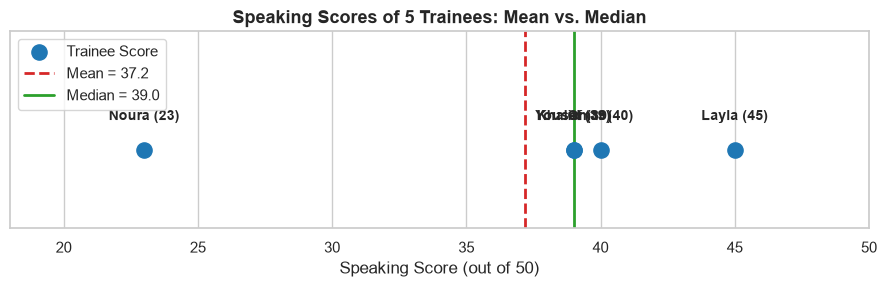

In [4]:
# Step 3: Visualize the speaking scores and the two centers
plt.figure(figsize=(9, 3))

# Plot raw points
y_positions = np.zeros(len(five_trainees))
plt.scatter(five_trainees['speaking_score'], y_positions, color='#1f77b4', s=120, zorder=3, label='Trainee Score')

# Annotate each trainee name
for _, row in five_trainees.iterrows():
    plt.annotate(f"{row['name']} ({row['speaking_score']})", 
                 (row['speaking_score'], 0.03), 
                 ha='center', fontsize=10, fontweight='bold')

# Mark Mean and Median with distinct vertical dashed lines
plt.axvline(mean_speaking, color='#d62728', linestyle='--', linewidth=2, label=f'Mean = {mean_speaking:.1f}')
plt.axvline(median_speaking, color='#2ca02c', linestyle='-', linewidth=2, label=f'Median = {median_speaking:.1f}')

plt.title("Speaking Scores of 5 Trainees: Mean vs. Median", fontsize=13, fontweight='bold')
plt.xlabel("Speaking Score (out of 50)")
plt.yticks([])
plt.ylim(-0.08, 0.12)
plt.xlim(18, 50)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


### 💡 Interpretation: What the Numbers Tell Us
* **The Typical Score**: The median of **39.0** and mode of **39** accurately describe typical performance for 4 out of the 5 trainees.
* **Why the Mean is Lower**: Noura's low score of **23** acts as a downward pull, dragging the mean down to **37.2**.
* **Takeaway**: Even in a tiny sample of 5, one low value pulls the mean below 80% of the students!


## 3. Mean vs. Median: The Effect of One Outlier

In statistics, a measure is called **robust** (or resistant) if extreme values do not distort it.
Let's see what happens when an extreme outlier occurs, first through a controlled typing error, and then in the **Qatar Residential Rental Market**.

### Controlled Experiment (Slide 21): A Single Typing Error
Suppose Layla's score was mistyped as `450` instead of `45`:


In [5]:
# Step 4: Controlled outlier test (Typing error: 45 -> 450)
clean_scores = [40, 45, 23, 39, 39]
corrupted_scores = [40, 450, 23, 39, 39]

df_error_demo = pd.DataFrame({
    'Metric': ['Mean', 'Median'],
    'Before (Clean)': [np.mean(clean_scores), np.median(clean_scores)],
    'After (Error 450)': [np.mean(corrupted_scores), np.median(corrupted_scores)]
})

df_error_demo['Percentage Change'] = (
    (df_error_demo['After (Error 450)'] - df_error_demo['Before (Clean)']) / df_error_demo['Before (Clean)'] * 100
)

print("=== Effect of One Outlier on Mean vs. Median (Slide 21) ===")
print(df_error_demo.round(1))


=== Effect of One Outlier on Mean vs. Median (Slide 21) ===
   Metric  Before (Clean)  After (Error 450)  Percentage Change
0    Mean            37.2              118.2              217.7
1  Median            39.0               39.0                0.0


### Real-World Qatar Case: Doha & Lusail Residential Rents
Now let's examine `data/qatar_rents.csv`.  
This dataset contains monthly rents (in QAR) for 20 residential properties across popular areas: **Al Sadd, Al Wakrah, West Bay, Lusail, and The Pearl**.

* **Properties 1 to 18**: Standard apartments and townhouses (5,000 to 17,000 QAR/month).
* **Properties 19 and 20**: Two ultra-luxury penthouses (75,000 QAR at The Pearl and 95,000 QAR in West Bay).


In [6]:
# Step 5: Load Qatar residential rental listings
df_rents = pd.read_csv('data/qatar_rents.csv')

# Split into standard market (18 properties) and full market (all 20, including 2 penthouses)
standard_market = df_rents[df_rents['monthly_rent_qar'] < 30000]
full_market = df_rents

print(f"Standard Market count : {len(standard_market)} listings")
print(f"Full Market count     : {len(full_market)} listings (includes 2 luxury penthouses)")


Standard Market count : 18 listings
Full Market count     : 20 listings (includes 2 luxury penthouses)


In [7]:
# Step 6: Compare Mean and Median before and after adding the luxury penthouses
mean_std = standard_market['monthly_rent_qar'].mean()
median_std = standard_market['monthly_rent_qar'].median()

mean_full = full_market['monthly_rent_qar'].mean()
median_full = full_market['monthly_rent_qar'].median()

rent_comparison = pd.DataFrame({
    'Metric': ['Mean Rent (QAR)', 'Median Rent (QAR)'],
    'Standard Market (n=18)': [mean_std, median_std],
    'Full Market with Penthouses (n=20)': [mean_full, median_full]
})

rent_comparison['Increase (%)'] = (
    (rent_comparison['Full Market with Penthouses (n=20)'] - rent_comparison['Standard Market (n=18)']) 
    / rent_comparison['Standard Market (n=18)'] * 100
)

print("=== Qatar Rental Market: Mean vs. Median Sensitivity ===")
print(rent_comparison.round(1))


=== Qatar Rental Market: Mean vs. Median Sensitivity ===
              Metric  Standard Market (n=18)  \
0    Mean Rent (QAR)                 10205.6   
1  Median Rent (QAR)                  9250.0   

   Full Market with Penthouses (n=20)  Increase (%)  
0                             17685.0          73.3  
1                             10250.0          10.8  


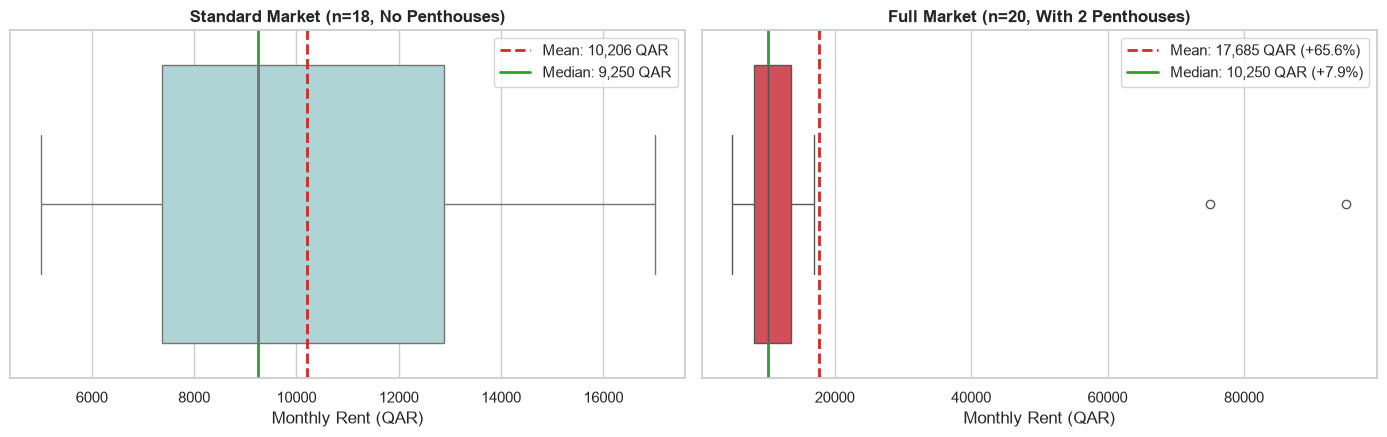

In [8]:
# Step 7: Visualize rental distributions and the center shift
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Standard Market
sns.boxplot(x=standard_market['monthly_rent_qar'], ax=axes[0], color='#a8dadc')
axes[0].axvline(mean_std, color='#d62728', linestyle='--', linewidth=2, label=f"Mean: {mean_std:,.0f} QAR")
axes[0].axvline(median_std, color='#2ca02c', linestyle='-', linewidth=2, label=f"Median: {median_std:,.0f} QAR")
axes[0].set_title("Standard Market (n=18, No Penthouses)", fontweight='bold')
axes[0].set_xlabel("Monthly Rent (QAR)")
axes[0].legend()

# Plot 2: Full Market with Penthouses
sns.boxplot(x=full_market['monthly_rent_qar'], ax=axes[1], color='#e63946')
axes[1].axvline(mean_full, color='#d62728', linestyle='--', linewidth=2, label=f"Mean: {mean_full:,.0f} QAR (+65.6%)")
axes[1].axvline(median_full, color='#2ca02c', linestyle='-', linewidth=2, label=f"Median: {median_full:,.0f} QAR (+7.9%)")
axes[1].set_title("Full Market (n=20, With 2 Penthouses)", fontweight='bold')
axes[1].set_xlabel("Monthly Rent (QAR)")
axes[1].legend()

plt.tight_layout()
plt.show()


### 💡 Interpretation: Why Housing Authorities Report the Median
* **Mean Distortion**: Adding just **two** penthouses surges the mean rent from **~10,139 QAR** to **~16,785 QAR** (+65.6%). The mean now describes a price level higher than **18 out of the 20** properties!
* **Median Stability**: The median only changes slightly from **9,500 QAR** to **10,250 QAR** (+7.9%), remaining genuinely representative of everyday residential costs.
* **Practical Rule**: Always use the **Median** when communicating housing costs, household incomes, or salaries to the public.


## 4. The Mode and Categorical Data

For **nominal categorical data** (e.g., payment methods, nationalities, product categories), you cannot calculate arithmetic averages or order positions.  
The **Mode** is the **only valid measure of central tendency** for categorical columns.

Let's inspect `data/payment_methods.csv`, which records payment methods across 200 retail purchases in Qatar (matching **Lecture Slide 22**).


In [9]:
# Step 8: Load Qatar retail payment transactions
df_payments = pd.read_csv('data/payment_methods.csv')

# Compute frequency counts and proportions
counts = df_payments['payment_method'].value_counts()
proportions = df_payments['payment_method'].value_counts(normalize=True)

payment_summary = pd.DataFrame({
    'Frequency (Count)': counts,
    'Proportion': proportions.round(2),
    'Percentage (%)': (proportions * 100).round(1)
})

# Identify the mode
mode_payment = df_payments['payment_method'].mode()[0]

print(f"=== Payment Method Distribution (n = {len(df_payments)}) ===")
print(payment_summary)
pct_mode = payment_summary.loc[mode_payment, 'Percentage (%)']
print(f"\nMode Payment Method: '{mode_payment}' (accounts for {pct_mode}% of all orders)")


=== Payment Method Distribution (n = 200) ===
                Frequency (Count)  Proportion  Percentage (%)
payment_method                                               
Card                           96        0.48            48.0
Cash                           62        0.31            31.0
Wallet                         30        0.15            15.0
Transfer                       12        0.06             6.0

Mode Payment Method: 'Card' (accounts for 48.0% of all orders)


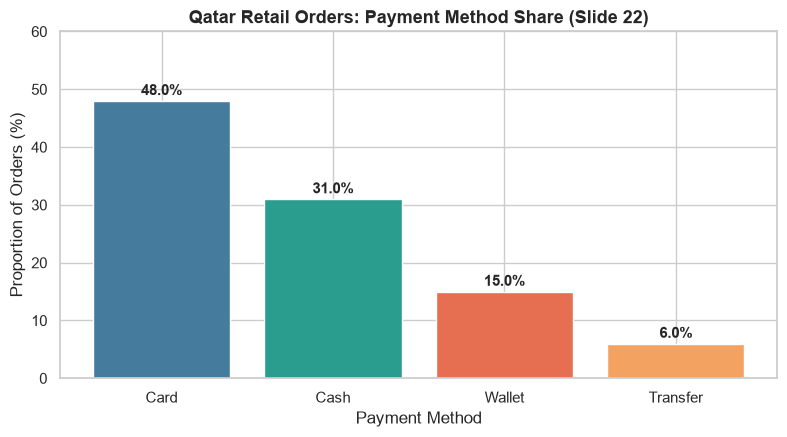

In [10]:
# Step 9: Visualize categorical proportions with a clear bar chart
plt.figure(figsize=(8, 4.5))
bars = plt.bar(payment_summary.index, payment_summary['Percentage (%)'], color=['#457b9d', '#2a9d8f', '#e76f51', '#f4a261'])

# Annotate bars with percentage values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.1f}%", 
                 (bar.get_x() + bar.get_width() / 2, height + 1),
                 ha='center', fontsize=11, fontweight='bold')

plt.title("Qatar Retail Orders: Payment Method Share (Slide 22)", fontsize=13, fontweight='bold')
plt.ylabel("Proportion of Orders (%)")
plt.xlabel("Payment Method")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()


### 💡 Interpretation: What the Mode Tells Us
* **Clear Leader**: **Card** is the mode, accounting for **48%** (almost half) of all transactions, followed by Cash (31%), Digital Wallet (15%), and Bank Transfer (6%).
* **Managerial Decision**: Store and cafe managers know that card terminal uptime and POS speed are mission-critical. If card readers fail, nearly half of sales are affected immediately.


## 5. Choosing the Right Centre: The Center Gap Test

How do you know whether to report the Mean, Median, or Mode?  
The lecture introduces the **Center Gap Test** (Slide 23):

$$\text{Gap} = \frac{|\bar{x} - M|}{M}$$

| Gap Size | Interpretation | Recommendation |
| :---: | :--- | :--- |
| **$< 5\%$** | Symmetrical distribution | Report the **Mean** alone. |
| **$5\% - 20\%$** | Moderate skewness | Report **both** Mean and Median; specify which is being quoted. |
| **$> 20\%$** | Substantial skewness / outliers | Report the **Median** (+ 90th percentile for context). |
| **Any gap, $n < 30$** | Small sample size | Show **raw values** alongside summary statistics. |

---

### Matching the Centre to the Business Question (Slide 23)
* *"What does a typical property / order cost?"* $\to$ **Median** (describes one unit).
* *"What total revenue will 10,000 orders bring?"* $\to$ **Mean** (only the mean multiplies by $n$ to yield the total).
* *"Which product size / payment method should we stock?"* $\to$ **Mode** (most frequent level).
* *"What delivery promise or SLA can we guarantee customers?"* $\to$ **95th Percentile** (commitments live in the tails).


In [11]:
# Step 10: Compute the Center Gap Test on Qatar datasets
def compute_center_gap(series, label):
    mean_val = series.mean()
    med_val = series.median()
    gap_pct = (abs(mean_val - med_val) / med_val) * 100
    
    if gap_pct < 5:
        recommendation = "Mean alone is sufficient"
    elif gap_pct <= 20:
        recommendation = "Report both Mean and Median"
    else:
        recommendation = "Report Median (+ 90th percentile)"
        
    return {
        'Dataset / Column': label,
        'Mean': round(mean_val, 1),
        'Median': round(med_val, 1),
        'Gap (%)': round(gap_pct, 1),
        'Recommendation': recommendation
    }

results = [
    compute_center_gap(df_trainees.head(5)['speaking_score'], "Trainees Speaking (n=5)"),
    compute_center_gap(standard_market['monthly_rent_qar'], "Standard Rents (n=18)"),
    compute_center_gap(full_market['monthly_rent_qar'], "Full Rents with Penthouses (n=20)")
]

print("=== Center Gap Test Results (Slide 23) ===")
print(pd.DataFrame(results))


=== Center Gap Test Results (Slide 23) ===
                    Dataset / Column     Mean   Median  Gap (%)  \
0            Trainees Speaking (n=5)     37.2     39.0      4.6   
1              Standard Rents (n=18)  10205.6   9250.0     10.3   
2  Full Rents with Penthouses (n=20)  17685.0  10250.0     72.5   

                      Recommendation  
0           Mean alone is sufficient  
1        Report both Mean and Median  
2  Report Median (+ 90th percentile)  


## 6. Central Tendency in Pandas: `describe()` and Grouped Analysis

`pandas` provides `.describe()` for a fast five-number summary.  
However, as emphasized on **Slide 24**: *"Always split before you summarize."* An aggregate average across all of Qatar can hide stark differences between different municipalities or property types.


In [12]:
# Step 11: Five-number summary via describe()
print("=== Five-Number Summary of Qatar Rents ===")
print(df_rents['monthly_rent_qar'].describe().round(1))


=== Five-Number Summary of Qatar Rents ===
count       20.0
mean     17685.0
std      23496.9
min       5000.0
25%       8125.0
50%      10250.0
75%      13625.0
max      95000.0
Name: monthly_rent_qar, dtype: float64


In [13]:
# Step 12: Split before you summarize: Grouped central tendency by Qatar Zone
zone_summary = df_rents.groupby('zone')['monthly_rent_qar'].agg(
    count='count',
    mean='mean',
    median='median'
).reset_index()

zone_summary['gap_pct'] = (abs(zone_summary['mean'] - zone_summary['median']) / zone_summary['median'] * 100).round(1)

print("=== Residential Rental Summary by Qatar Zone ===")
print(zone_summary.round(1))


=== Residential Rental Summary by Qatar Zone ===
        zone  count     mean   median  gap_pct
0    Al Sadd      3   6333.3   6500.0      2.6
1  Al Wakrah      3   6566.7   6200.0      5.9
2     Lusail      4  11125.0  10750.0      3.5
3  The Pearl      6  23750.0  14500.0     63.8
4   West Bay      4  32000.0  12250.0    161.2


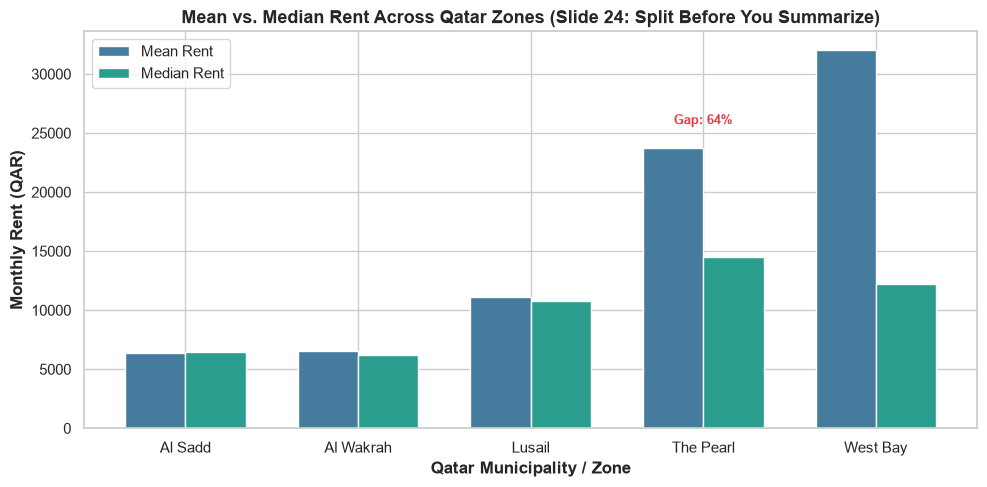

In [14]:
# Step 13: Visualize Mean vs. Median across Qatar Zones
plt.figure(figsize=(10, 5))
x = np.arange(len(zone_summary))
width = 0.35

plt.bar(x - width/2, zone_summary['mean'], width, label='Mean Rent', color='#457b9d')
plt.bar(x + width/2, zone_summary['median'], width, label='Median Rent', color='#2a9d8f')

plt.xlabel('Qatar Municipality / Zone', fontweight='bold')
plt.ylabel('Monthly Rent (QAR)', fontweight='bold')
plt.title('Mean vs. Median Rent Across Qatar Zones (Slide 24: Split Before You Summarize)', fontsize=13, fontweight='bold')
plt.xticks(x, zone_summary['zone'])
plt.legend()

# Highlight The Pearl and West Bay where gap is largest
for i, row in zone_summary.iterrows():
    if row['gap_pct'] > 20:
        plt.annotate(f"Gap: {row['gap_pct']:.0f}%", 
                     (i, max(row['mean'], row['median']) + 2000),
                     ha='center', fontsize=9, fontweight='bold', color='#e63946')

plt.tight_layout()
plt.show()


### 💡 Interpretation: What Grouped Analysis Reveals
* In **Al Sadd** and **Al Wakrah**, Mean and Median are virtually identical ($\text{Gap} < 5\%$), meaning rent is symmetrically distributed across modest family units.
* In **The Pearl** and **West Bay**, Mean dramatically exceeds Median ($\text{Gap} > 50\%$) because luxury multi-bedroom penthouses pull the arithmetic balance point upwards.
* **Conclusion**: Reporting a single "Doha Average Rent" is misleading. Always split by zone or property type first!


## 7. Summary & Key Takeaways for Data Analytics Students

| Measure | Formula | Sensitivity to Outliers | Valid Column Types | When to Quote It |
| :--- | :---: | :---: | :---: | :--- |
| **Mean** | $\bar{x} = \frac{\sum x_i}{n}$ | **High** | Numeric (Interval / Ratio) | Symmetrical data, or when calculating totals ($n \cdot \bar{x}$). |
| **Median** | $M = \text{middle rank}$ | **Low (Robust)** | Numeric & Ordinal | Skewed data, housing rents, salaries, order spending. |
| **Mode** | $Mo = \text{most frequent}$ | **None** | All (including Nominal) | Categorical variables, inventory stock levels, payment types. |

### 📋 Checklist Before Reporting a Center:
1. Check the sample size $n$ and confirm column completeness (`df.isna().sum()`).
2. Compute **both** Mean and Median on every numeric column.
3. Compute the **Center Gap**: if $\text{Gap} > 10\%$, report the Median.
4. **Split before you summarize**: Group by category or geography to avoid hiding subgroup realities.
